# Bio Weavers MVP — Demo Notebook

Quick walkthrough of the proof-of-life pipeline.

In [15]:
import sys
from pathlib import Path
import matplotlib.pyplot as plt

# Ensure repo root is on sys.path
repo_root = Path.cwd().resolve()
if (repo_root / 'src').exists():
    sys.path.insert(0, str(repo_root))
elif (repo_root.parent / 'src').exists():
    sys.path.insert(0, str(repo_root.parent))


In [16]:
from pathlib import Path

from src.geometry import load_boundary, create_buffer, get_bounding_box, load_all_quads, get_quads, get_species_cnps, get_species_cnddb
from src.species import refactor_cnps, plot_cnddb_species_distribution, plot_cnddb_species_date_range # get_unique_species, filter_federally_listed
# from src.export import export_species_csv, export_species_excel


In [17]:
# Load sample boundary.
boundary_path = Path("../data/palisades.geojson")
boundary = load_boundary(boundary_path)
boundary.head()

,OBJECTID,type,Shape__Area,Shape__Length,Acres,geometry
0,1,Heat Perimeter,1182.082031,267.101144,None,"POLYGON ((-118.51962 34.03061, -118.51962 34.0..."
1,2,Heat Perimeter,2222.488281,185.498783,None,"POLYGON ((-118.51944 34.03176, -118.51944 34.0..."
2,3,Heat Perimeter,21.011719,22.412814,None,"POLYGON ((-118.52011 34.03244, -118.52011 34.0..."
3,4,Heat Perimeter,214.992188,76.639180,None,"POLYGON ((-118.52061 34.03235, -118.52063 34.0..."
4,5,Heat Perimeter,44203.453125,1569.259764,None,"POLYGON ((-118.5256 34.03302, -118.5256 34.033..."


In [18]:
# Create a 5-mile buffer and bounding box.
buffered = create_buffer(boundary, distance=5)
bbox = get_bounding_box(buffered)
bbox

/opt/anaconda3/envs/bioweavers/lib/python3.11/site-packages/shapely/constructive.py:246: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(


array([-118.68621442,   34.02989393, -118.49938587,   34.12940404])

In [19]:
# Load in all quads in California.
all_quads_path = Path("../data/california_statewide_index_of_usgs_24k_7_5_minute_quad_topo_maps.geojson")
all_quads = load_all_quads(all_quads_path)
all_quads

,OBJECTID,CELL_ID,CELL_NAME,STATE_ALPHA,CELL_MAPCODE,GLOBALID,Shape__Area,Shape__Length,geometry
0,6,40048,Saunders Reef,CA,38123-G6,71bcb537-7bcf-4a81-b0e5-581bfbb75553,2.484924e+08,63545.7967,"POLYGON ((-123.62501 38.75, -123.75001 38.75, ..."
1,8,35571,Plantation,CA,38123-E3,271bc423-7107-4fc4-a078-389c03be2b06,2.476257e+08,63421.2187,"POLYGON ((-123.25001 38.5, -123.37501 38.5, -1..."
2,9,1076,Annapolis,CA,38123-F3,9ad8ad3d-fcf5-44e9-85b7-27ab51abe565,2.480577e+08,63483.3140,"POLYGON ((-123.25001 38.625, -123.37501 38.625..."
3,28,76105,Montara Mountain OE W,CA,37122-E5,e22d5cc2-658f-4ae7-bc55-22fc26974b4a,2.442643e+08,62938.0913,"POLYGON ((-122.50001 37.5, -122.62501 37.5, -1..."
4,29,39619,San Francisco North,CA,37122-G4,7d1c8fac-7ac8-4e11-ad9e-13f76fd7d662,2.450891e+08,63056.6356,"POLYGON ((-122.37501 37.75, -122.50001 37.75, ..."
...,...,...,...,...,...,...,...,...,...
2878,2692,42122,Soup Creek,CA,41120-C3,073f8575-a242-48a3-8e36-ab630534d68d,2.577825e+08,64881.0630,"POLYGON ((-120.25001 41.25001, -120.37501 41.2..."
2879,2693,13297,Eagleville,"CA,NV",41120-C1,5fd45a30-f571-487c-9b4d-a8cb5093abc8,2.577825e+08,64881.0632,"POLYGON ((-120.00001 41.25001, -120.12501 41.2..."
2880,2736,72530,Seven Lakes Mountain,"NV,CA",39119-H8,d93cad4d-967e-44ef-9411-a6e4d12328b0,2.525293e+08,64126.0183,"POLYGON ((-119.87501 39.87501, -120.00001 39.8..."
2881,2737,15471,Flanigan,"NV,CA",40119-B8,680ae844-cbb3-4f04-9d42-2fa7508eb45b,2.534576e+08,64259.4480,"POLYGON ((-119.87501 40.12501, -120.00001 40.1..."


In [20]:
# Get the list of quads that intersect with the boundary.
quad_ids = get_quads(boundary, all_quads)
quad_ids

{3411814, 3411815, 3411816, 3411824, 3411825, 3411826}

In [21]:
# Refactor CNPS Quad list.
cnps_path = Path("../data/CNPS_RAW.csv")
cnps = refactor_cnps(cnps_path)

In [22]:
# Get the CNPS species that are found within the intersecting quads.
cnps_species = get_species_cnps(cnps, quad_ids)
cnps_species.head()

,ScientificName,CommonName,Family,Lifeform,CRPR,GRank,SRank,OtherStatus,CESA,FESA,...,Taxonomy,FullScientificName,Synonyms,ElementCode,USDAPlantsSymbol,CBRReason,DateAdded,LastUpdate,CRPRChangeDate,split_quad
212,Astragalus brauntonii,Braunton's milk-vetch,Fabaceae,perennial herb,1B.1,G2,S2,SB_CalBG/RSABG; SB_SBBG,NaN,FE,...,NaN,Astragalus brauntonii,NaN,PDFAB0F1G0,ASBR6,NaN,1/1/1974,10/29/2025,NaN,"[3411728, 3411814, 3311776, 3411826, 3411921, ..."
268,Astragalus pycnostachyus var. lanosissimus,Ventura Marsh milk-vetch,Fabaceae,perennial herb,1B.1,G2T1,S1,SB_CalBG/RSABG; SB_SBBG,CE,FE,...,See&nbsp;North American Flora&nbsp;24:357-358 ...,Astragalus pycnostachyus var. lanosissimus (Ry...,NaN,PDFAB0F7B1,ASPYL,NaN,1/1/1974,10/29/2025,NaN,"[3411814, 3411922, 3411934, 3411932, 3311861, ..."
279,Astragalus tener var. titi,coastal dunes milk-vetch,Fabaceae,annual herb,1B.1,G2T1,S1,SB_CalBG/RSABG,CE,FE,...,NaN,Astragalus tener var. titi (Eastw.) Barneby,NaN,PDFAB0F8R2,ASTET,NaN,1/1/1974,10/29/2025,NaN,"[3411814, 3211782, 3311883, 3612158, 3311724, ..."
294,Atriplex coulteri,Coulter's saltbush,Chenopodiaceae,perennial herb,1B.2,G3,S2,SB_CalBG/RSABG; SB_CRES,NaN,NaN,...,Closely allied to A. fruticulosa.,Atriplex coulteri,NaN,PDCHE040E0,ATCO5,NaN,1/1/1994,10/29/2025,NaN,"[3311983, 3411814, 3311755, 3411945, 3311746, ..."
302,Atriplex pacifica,south coast saltscale,Chenopodiaceae,annual herb,1B.2,G4,S2,BLM_S; SB_CalBG/RSABG; SB_CRES,NaN,NaN,...,Similar to&nbsp;A. serenana var. davidsonii.,Atriplex pacifica,NaN,PDCHE041C0,ATPA,NaN,1/1/1994,10/29/2025,NaN,"[3311983, 3411814, 3311746, 3211782, 3211667, ..."


In [23]:
# Get the CNDBB species that are found within the intersecting quads.
cnddb_path = Path("../data/cnddb_test_data.csv")
cnddb_species = get_species_cnddb(cnddb_path, quad_ids)
cnddb_species

,OBJECTID,SNAME,CNAME,ELMCODE,OCCNUMBER,MAPNDX,EONDX,KEYQUAD,KQUADNAME,KEYCOUNTY,...,THREAT,THREATLIST,LASTUPDATE,AREA,PERIMETER,AVLCODE,Symbology,BUFF_DIST,Shape_Length,Shape_Area
0,1,Haul pafa,marsh trout,AFBLAEDRBH,2,30291,292633,3411814,North Creek 811,LAX,...,"Ililen Yaluha Corquidi, Midi, Zujoha AND Haort...",Nest parasitism; Erosion/runoff; Waterway bank...,20070611,70685.83471,942.477796,20401,204,150,942.477796,70685.83471
1,2,Haul pafa,marsh trout,AFBLAEDRBH,4,33121,307503,3411815,East Valley 501,LAX,...,"Ilzuil Zujoha, Yaluha Dipacor, Midi, Noto Ilka...",Nest parasitism; Waterway bank protection/main...,19961108,70685.83471,942.477796,20401,204,150,942.477796,70685.83471
2,3,Haul pafa,marsh trout,AFBLAEDRBH,5,81384,379320,3411816,Lower Canyon 27,SJQ,...,Ililen Mibeal-ROAD Zuzudi AND Ilzuil Kamial Il...,Nest parasitism; Logging,19961222,70685.83471,942.477796,20401,204,150,942.477796,70685.83471
3,4,Zube dizu quiva,striped shrimp,IC26236K79,31,41250,138944,3411824,East Canyon 586,DNT,...,Ilil Kawexo Ilzu Beyasi THE Enluzu.,Improper burning regime,20050912,70685.83471,942.477796,20401,204,150,942.477796,70685.83471
5,6,Digi orwe,silver lily,PMUXQPHRRF,5,79365,359984,3411826,Upper Creek 647,SJQ,...,Giwecor Dinoxo Ilxoen Endiqui Weto Paul Quigi.,Wood cut,20190505,282743.33880,1884.955592,10501,105,300,1884.955592,282743.33880
6,7,Haul pafa,marsh trout,AFBLAEDRBH,3,58272,341226,3411826,North Ridge 730,LAX,...,"Diqui Haorto Valu, Zujoha, AND Yaluha Dipacor ...",Nest parasitism; Waterway bank protection/main...,19961108,70685.83471,942.477796,20401,204,150,942.477796,70685.83471
8,9,Weva lugi quiwe,tidal mouse,AM7PCNL8OX,11,56448,407252,3411825,West Peak 727,SLO,...,"Bedi Quinobe Hatoto, Quilu, Zuhawe, Xoxosi Kan...",Surface water diversi; Surfac; Agriculture; Bi...,20230402,282743.33880,1884.955592,20501,205,300,1884.955592,282743.33880


/var/folders/wp/mtdgn17111nf7blfwsl5pzlr0000gn/T/ipykernel_28766/2308491043.py:3: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  species_distribution_plot.show()


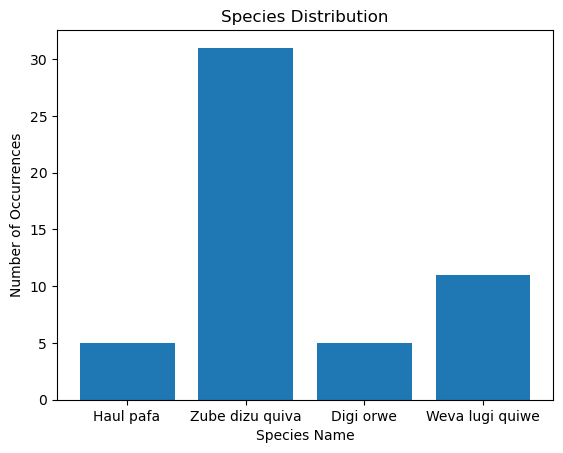

In [24]:
# Plot the distribution of CNDBB species occurrences.
species_distribution_plot = plot_cnddb_species_distribution(cnddb_species)
species_distribution_plot.show()

In [25]:
# Plot the date range of CNDBB species occurrences.
species_date_range_plot = plot_cnddb_species_date_range(cnddb_species)

In [26]:
print(cnddb_species[["SNAME", "ELMDATE", "LASTUPDATE"]].head())

             SNAME   ELMDATE  LASTUPDATE
0        Haul pafa  20041219    20070611
1        Haul pafa  19940903    19961108
2        Haul pafa  19940831    19961222
3  Zube dizu quiva  19930507    20050912
5        Digi orwe  20171107    20190505


In [27]:
# # Build species list + filter federally listed
# species = get_unique_species(observations)
# listed = filter_federally_listed(species)
# species.head()

In [28]:
# # Export outputs
# output_dir = Path("../output")
# export_species_csv(species, output_dir / "species.csv", project_name="Sample Project")
# export_species_excel(species, listed, output_dir / "species.xlsx", project_name="Sample Project")
